In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df=pd.read_csv('books_cleaned.csv')  # Replace with your actual data source
df.head(5)

,Title,Price,Rating,Availability,Stock,Price_Range,Rating_Group,Stock_Status
0,A Light in the Attic,51.77,3,In stock,1,High,Average,Available
1,Tipping the Velvet,53.74,1,In stock,1,High,Poor,Available
2,Soumission,50.10,1,In stock,1,High,Poor,Available
3,Sharp Objects,47.82,4,In stock,1,High,Good,Available
4,Sapiens A Brief History of Humankind,54.23,5,In stock,1,High,Excellent,Available


# Univariate Analysis

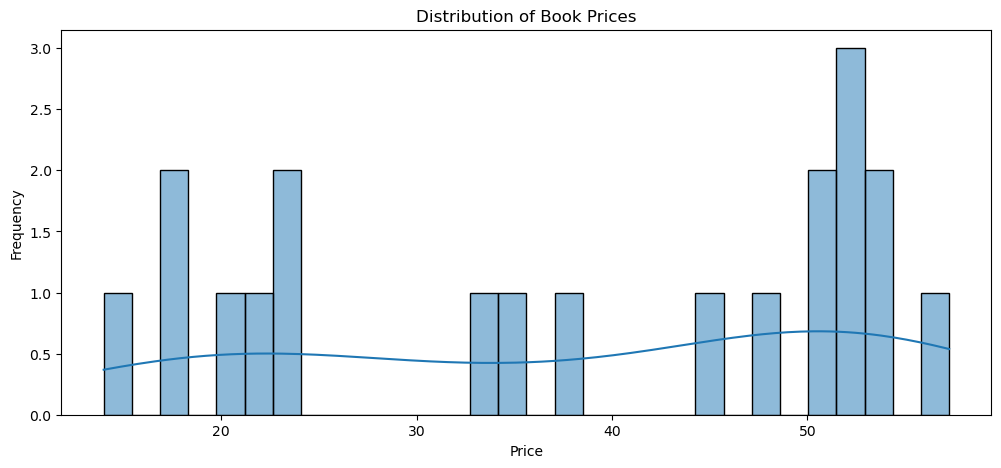

In [32]:

# Distribution of book prices and ratings

plt.figure(figsize=(12, 5))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title('Distribution of Book Prices');plt.xlabel('Price');plt.ylabel('Frequency');plt.show()

Text(0, 0.5, 'Count')

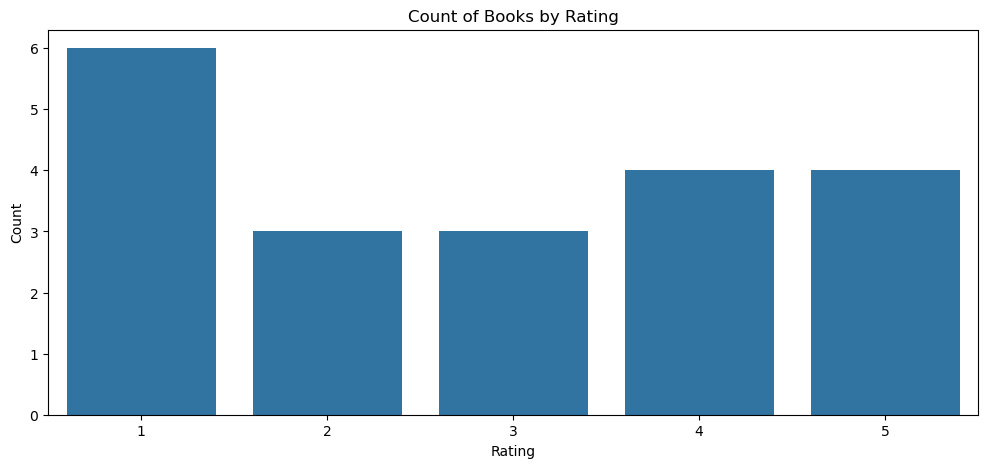

In [33]:
# Count plots for categorical variables (rating, stock status)

plt.figure(figsize=(12, 5))

sns.countplot(x='Rating', data=df)
plt.title('Count of Books by Rating');plt.xlabel('Rating');plt.ylabel('Count')



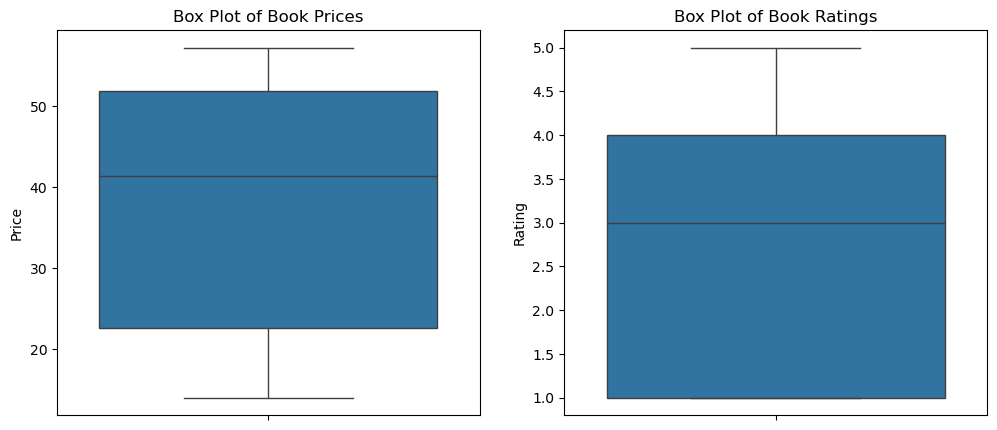

In [35]:
# Box plots for Price and Rating

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y='Price', data=df)
plt.title('Box Plot of Book Prices');plt.ylabel('Price')

plt.subplot(1, 2, 2)
sns.boxplot(y='Rating', data=df)
plt.title('Box Plot of Book Ratings');plt.ylabel('Rating')
plt.show() 



# Bivariate Analysis

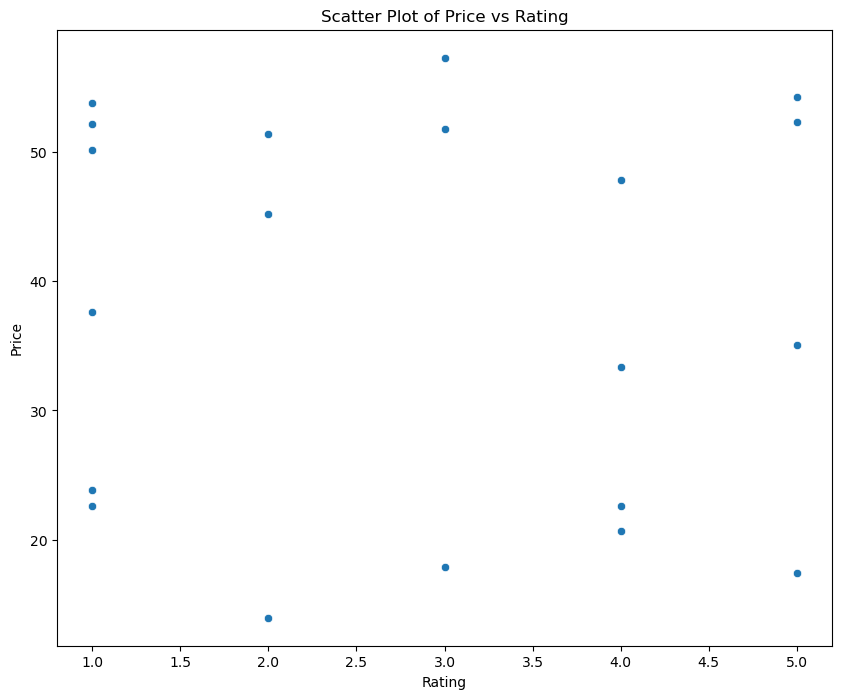

In [37]:


plt.figure(figsize=(10, 8))
sns.scatterplot(x='Rating', y='Price', data=df)
plt.title('Scatter Plot of Price vs Rating');plt.show()

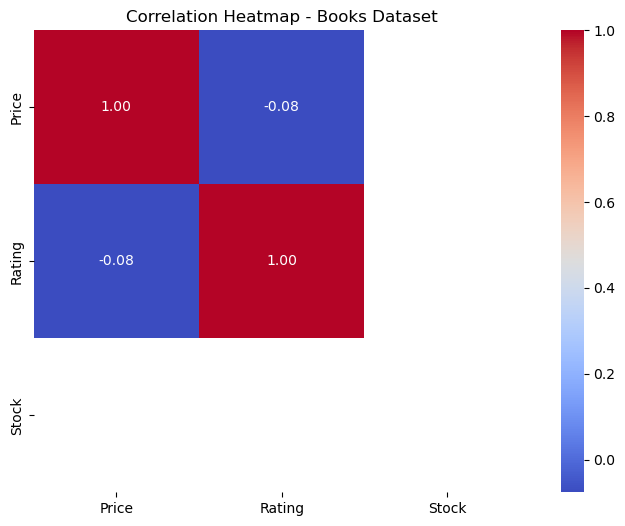

In [38]:
# Correlation heatmap (numerical features)

numeric_df = df[["Price", "Rating", "Stock"]]

# Calculate correlation
correlation = numeric_df.corr()

# Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Books Dataset")
plt.show()

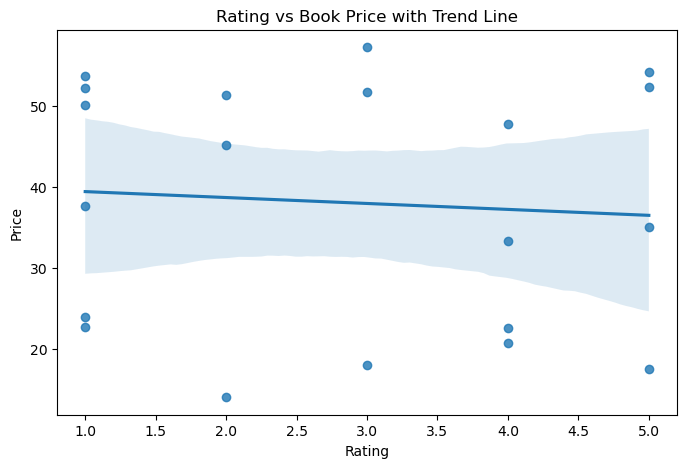

In [39]:
# Scatter Plot with Trend Line
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Rating",
    y="Price"
)

plt.title("Rating vs Book Price with Trend Line")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.show()


# Multivariate Analysis

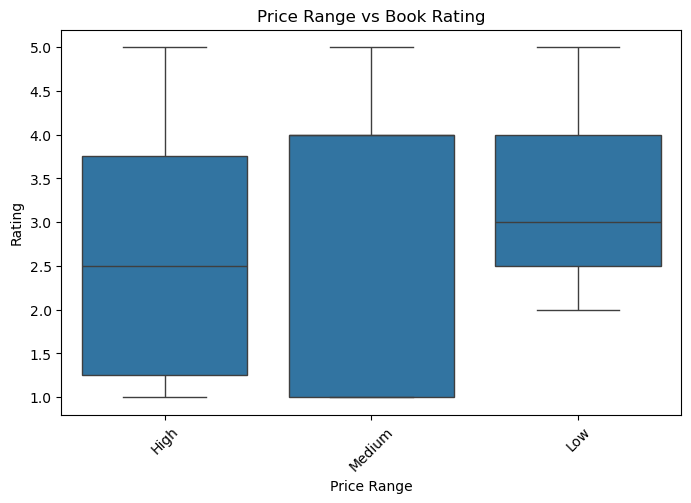

In [41]:
# Price Range vs Book Rating

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Price_Range",
    y="Rating"
)

plt.title("Price Range vs Book Rating")
plt.xlabel("Price Range")
plt.ylabel("Rating")
plt.xticks(rotation=45)

plt.show()

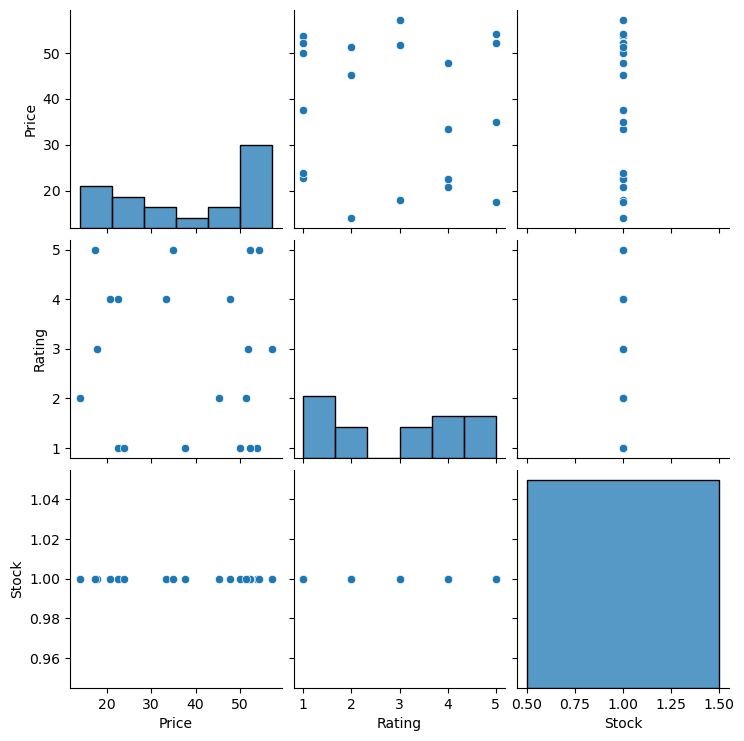

In [42]:
# Pair Plot

sns.pairplot(
    df[["Price", "Rating", "Stock"]]
)

plt.show()

# Advanced EDA


In [43]:
# Outlier Analysis and Impact

Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Price"] < lower) |
    (df["Price"] > upper)
]

print(outliers)

Empty DataFrame
Columns: [Title, Price, Rating, Availability, Stock, Price_Range, Rating_Group, Stock_Status]
Index: []


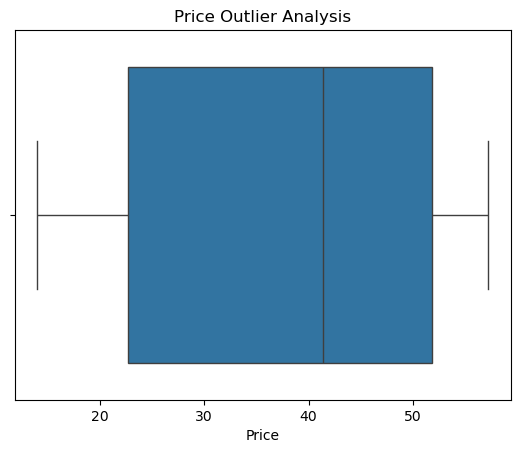

In [44]:
sns.boxplot(x=df["Price"])

plt.title("Price Outlier Analysis")
plt.show()


# Insights Generation

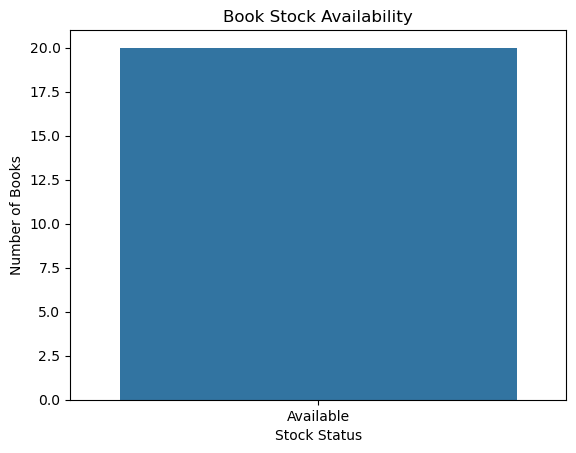

In [45]:
# Stock Availability :

sns.countplot(
    x="Stock_Status",
    data=df
)

plt.title("Book Stock Availability")
plt.xlabel("Stock Status")
plt.ylabel("Number of Books")
plt.show()

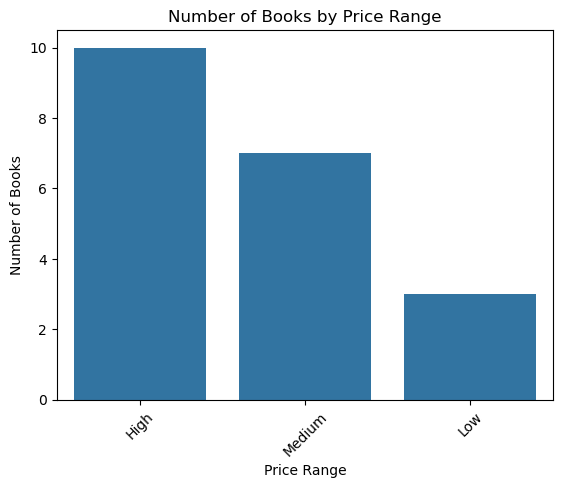

In [47]:
# Books by price range:

sns.countplot(
    x="Price_Range",
    data=df
)

plt.title("Number of Books by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.show()

In [48]:
df.to_csv("Visualized_Product_data.csv")